In [1]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

print("X Shape",X.shape)
print("y shape",y.shape)


X Shape (569, 30)
y shape (569,)


In [2]:
print(data.target_names)

['malignant' 'benign']


In [3]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [4]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix ,classification_report

svm_linear = SVC(
    kernel='linear',
    C=1
)

svm_linear.fit(X_train_scaled,y_train)

y_pred= svm_linear.predict(X_test_scaled)

print("accuracy:" , accuracy_score(y_pred,y_test) )

print("\nConfusion matrix:")
print(confusion_matrix(y_pred,y_test))
print("\nClassification Report:")
print(classification_report(y_pred,y_test))

accuracy: 0.956140350877193

Confusion matrix:
[[41  3]
 [ 2 68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        44
           1       0.96      0.97      0.96        70

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [6]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix ,classification_report

svm_linear = SVC(
    kernel='rbf',
    C=1
)

svm_linear.fit(X_train_scaled,y_train)

y_pred= svm_linear.predict(X_test_scaled)

print("accuracy:" , accuracy_score(y_pred,y_test) )

print("\nConfusion matrix:")
print(confusion_matrix(y_pred,y_test))
print("\nClassification Report:")
print(classification_report(y_pred,y_test))

accuracy: 0.9824561403508771

Confusion matrix:
[[41  0]
 [ 2 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        41
           1       1.00      0.97      0.99        73

    accuracy                           0.98       114
   macro avg       0.98      0.99      0.98       114
weighted avg       0.98      0.98      0.98       114



In [7]:
for gamma in [0.001, 0.01 , 0.1 , 1 ]:

    model= SVC(
        kernel='rbf',
        C=1,
        gamma=gamma
    )

    model.fit(X_train_scaled,y_train)

    training_accuracy = model.score(X_train_scaled,y_train)
    test_accuracy = model.score(X_test_scaled,y_test)

    print(
        "gamma:",gamma,
        "train_accuracy:",training_accuracy, 
        "test_accuracy:",test_accuracy
    )

gamma: 0.001 train_accuracy: 0.9472527472527472 test_accuracy: 0.9649122807017544
gamma: 0.01 train_accuracy: 0.9736263736263736 test_accuracy: 0.9649122807017544
gamma: 0.1 train_accuracy: 0.9934065934065934 test_accuracy: 0.9649122807017544
gamma: 1 train_accuracy: 1.0 test_accuracy: 0.631578947368421


In [8]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C":[0.1,1,10,100],
    "gamma":[0.001,0.01,0.1,1],
    "kernel":["rbf"]
}

grid = GridSearchCV(
    estimator= SVC(),
    param_grid=param_grid,
    cv=5,
    scoring= "accuracy"
)

In [9]:
grid.fit(X_train_scaled,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1],
                         'kernel': ['rbf']},
             scoring='accuracy')

In [10]:
print("Best Parameters:",grid.best_params_)
print("Best Score :",     grid.best_score_)

Best Parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best Score : 0.9736263736263737


In [11]:
best_model=grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

In [12]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(y_pred,y_test)

print("Final test Accuracy:",test_accuracy)

Final test Accuracy: 0.9824561403508771


In [13]:
from sklearn.metrics import confusion_matrix,classification_report

print("\nConfusion Matrix")
print(confusion_matrix(y_pred,y_test))
print("\nClassification Report")
print(classification_report(y_pred,y_test))


Confusion Matrix
[[41  0]
 [ 2 71]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        41
           1       1.00      0.97      0.99        73

    accuracy                           0.98       114
   macro avg       0.98      0.99      0.98       114
weighted avg       0.98      0.98      0.98       114



In [15]:
from sklearn.metrics import roc_auc_score

y_scores = best_model.decision_function(X_test_scaled)

auc = roc_auc_score(y_test,y_scores)

print("ROC-AUC",auc)


ROC-AUC 0.99737962659679


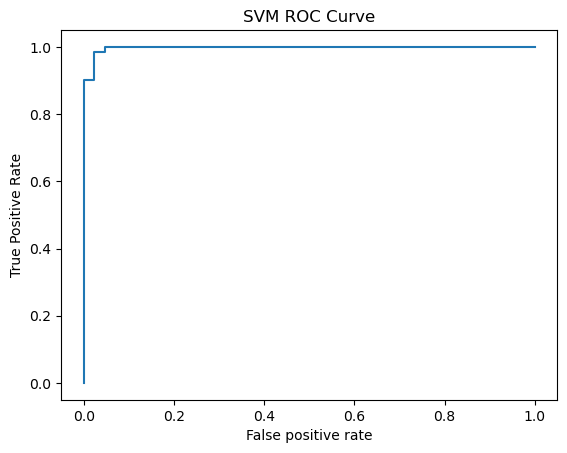

In [16]:
from sklearn.metrics import roc_curve

import matplotlib.pyplot as plt

fpr,tpr,thresholds = roc_curve(y_test,y_scores)

plt.plot(fpr,tpr)
plt.xlabel("False positive rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.show()